# ⚡ Vectors, Matrices, and NumPy Optimization

In modern AI engineering, writing explicit Python `for` loops is a major performance bottleneck.
NumPy provides **vectorized C-backed arrays**, **broadcasting**, and **high-performance matrix operations**.

In this notebook, we explore NumPy's core mechanics and build a **Markov Chain simulator**.


---
## 1. Vectorization Speed Benchmark

Let's compare Python loops vs NumPy vectorization for computing element-wise math across 1,000,000 numbers.


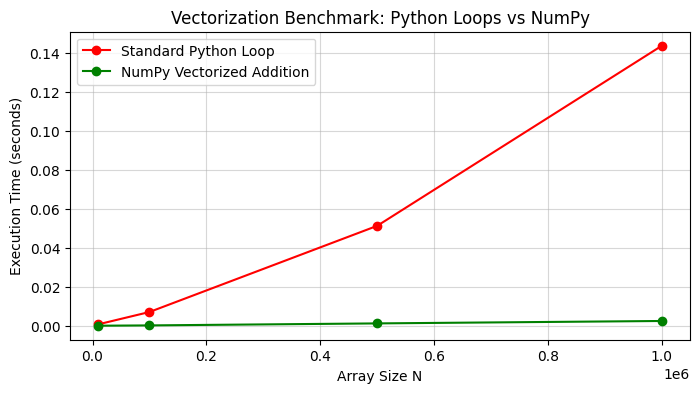

Speedup for 1M elements: 57.6x faster!


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

sizes = [10000, 100000, 500000, 1000000]
py_times = []
np_times = []

for N in sizes:
    a = list(range(N))
    b = list(range(N))
    
    # Python loop
    t0 = time.time()
    res_py = [a[i] + b[i] for i in range(N)]
    py_times.append(time.time() - t0)
    
    # NumPy vectorization
    a_np = np.array(a)
    b_np = np.array(b)
    t0 = time.time()
    res_np = a_np + b_np
    np_times.append(time.time() - t0)

plt.figure(figsize=(8, 4))
plt.plot(sizes, py_times, 'r-o', label='Standard Python Loop')
plt.plot(sizes, np_times, 'g-o', label='NumPy Vectorized Addition')
plt.xlabel('Array Size N')
plt.ylabel('Execution Time (seconds)')
plt.title('Vectorization Benchmark: Python Loops vs NumPy')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print(f'Speedup for 1M elements: {py_times[-1] / np_times[-1]:.1f}x faster!')


---
## 2. Broadcasting Mechanics Heatmap

Broadcasting allows arithmetic operations on arrays of different shapes without copying data.


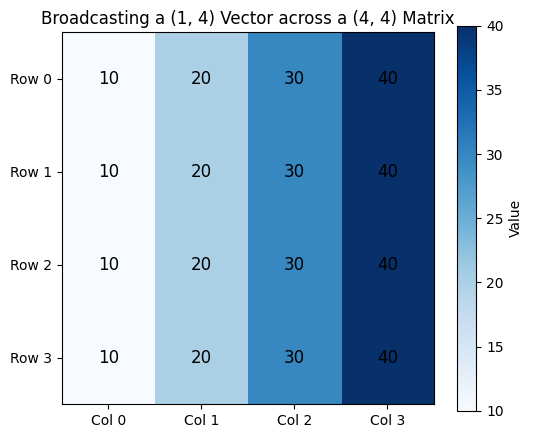

In [2]:
matrix = np.zeros((4, 4))
row_vec = np.array([10, 20, 30, 40])

# Broadcast addition
broadcast_result = matrix + row_vec

plt.figure(figsize=(6, 5))
plt.imshow(broadcast_result, cmap='Blues')
plt.colorbar(label='Value')
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{int(broadcast_result[i, j])}', ha='center', va='center', fontsize=12)
plt.title('Broadcasting a (1, 4) Vector across a (4, 4) Matrix')
plt.xticks(range(4), ['Col 0', 'Col 1', 'Col 2', 'Col 3'])
plt.yticks(range(4), ['Row 0', 'Row 1', 'Row 2', 'Row 3'])
plt.show()


---
## 3. Markov Chain Customer Journey Simulator

A Markov Chain tracks probabilistic state transitions over time using matrix multiplication: $\mathbf{x}_{t+1} = \mathbf{x}_t P$.


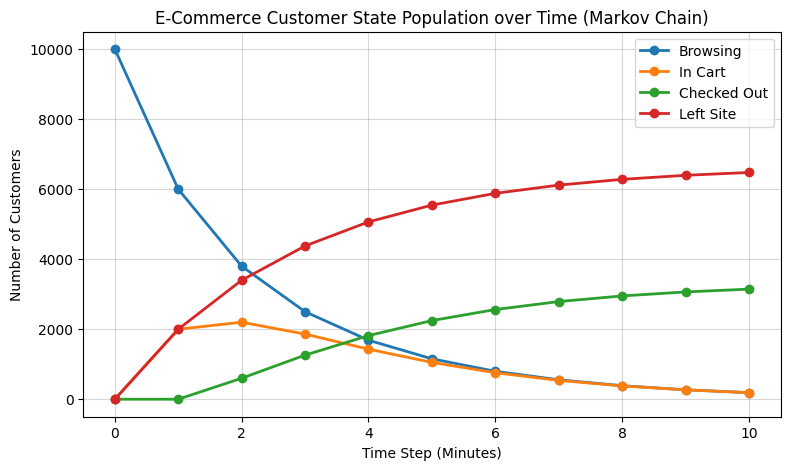

In [3]:
states = ['Browsing', 'In Cart', 'Checked Out', 'Left Site']
transition_matrix = np.array([
    [0.60, 0.20, 0.00, 0.20],  # From Browsing
    [0.10, 0.50, 0.30, 0.10],  # From Cart
    [0.00, 0.00, 1.00, 0.00],  # Checked Out (Terminal)
    [0.00, 0.00, 0.00, 1.00]   # Left Site (Terminal)
])

# Initial state: 10,000 browsing users
state_history = []
current = np.array([10000.0, 0.0, 0.0, 0.0])
state_history.append(current)

steps = 10
for _ in range(steps):
    current = current @ transition_matrix
    state_history.append(current)

history_arr = np.array(state_history)

plt.figure(figsize=(9, 5))
for idx, name in enumerate(states):
    plt.plot(range(steps + 1), history_arr[:, idx], '-o', linewidth=2, label=name)

plt.title('E-Commerce Customer State Population over Time (Markov Chain)')
plt.xlabel('Time Step (Minutes)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()
